# D2 – Monte-Carlo & Mandelbrot

**Python numérique – devoir n° 2 – à rendre pour le vendredi 25 septembre 2026, 18 h** (la séance 3 est le mardi 29)

Bienvenue dans votre deuxième devoir ! Nous allons y mettre en pratique les notions vues en séance 2 : fonctions vectorisées (`ufunc`), agrégations avec `axis`, *broadcasting*, masques booléens et générateur de nombres aléatoires. Le sujet comporte trois parties indépendantes, avec une règle commune : on ne boucle jamais sur les points, les tirages ou les pixels. La seule boucle Python autorisée est celle sur les itérations de la partie C (et, le cas échéant, une petite boucle sur quelques graines aléatoires en A.3).

Vous avez deux semaines devant vous ; durée indicative : 2 h 30.

````{admonition} Consignes de rendu
:class: important

* Ce notebook reste dans le dossier `D2/` de votre dépôt `pe-homework` (celui que le zip du sujet a créé en se dézippant), avec ses figures à côté, puis il doit être **commité et poussé** (`git add`, `git commit`, `git push`) avant la deadline. Attention, c'est la **date du commit** qui fait foi, pas celle du push ; le nom du fichier, lui, n'a pas d'importance (`sujet.ipynb` convient très bien).
* Juste avant de rendre, **pensez à ré-exécuter toutes les cellules** via *Kernel → Restart Kernel and Run All Cells* : toutes doivent s'exécuter dans l'ordre et sans erreur. En effet, un notebook qui plante à mi-chemin sera corrigé jusqu'à l'erreur…
* Les trois figures demandées (`pi.png`, `marche.png` et `mandelbrot.png`) sont à enregistrer dans le dossier du notebook (`plt.savefig`), et doivent aussi apparaître dans le notebook. Pensez à les habiller : une figure sans titre, sans légende ou sans nom d'axes perdra des points.
* Les cellules `# votre code` sont à compléter ; vous pouvez ajouter autant de cellules que vous le souhaitez. Les cellules de test (`assert`) sont là pour vous aider : si elles passent sans erreur, c'est bon signe. Ne les modifiez pas !
* Répondez aux questions "en français" dans une cellule *Markdown*, en deux ou trois phrases.
````

````{admonition} Ce qui est autorisé
:class: note

* La documentation de `numpy` / `matplotlib`, les notebooks du cours, vos notes.
* Les assistants IA sont tolérés, avec la même règle qu'au D1 : **vous devez être capable d'expliquer chaque ligne que vous rendez**, et je pourrai vous demander de le faire à l'oral en séance. Le devoir est individuel.
* En revanche, les boucles `for` / `while` sur les éléments d'un tableau (points, pas, pixels) restent interdites : une solution correcte mais qui boucle sur les éléments vaudra au plus la moitié des points de la question.
````

## Barème

| Partie | Contenu | Points |
|---|---|---|
| A | Monte-Carlo : estimation de π, convergence, `pi.png` | 6 |
| B | Marches aléatoires 2D vectorisées, `marche.png` | 6 |
| C | Ensemble de Mandelbrot, `mandelbrot.png` | 6 |
| – | Notebook propre : exécuté sans erreur, code vectorisé, figures légendées, réponses rédigées | 2 |
| **Total** | | **20** |
| Bonus | Zoom, palette, itération sans avertissement | +2 |

*Inspiré des exercices de <https://numerique-exos.info-mines.paris>.*

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

## Partie A – Estimer π par la méthode de Monte-Carlo (6 pts)

Le principe est le suivant : on tire `n` points uniformément dans le carré $[-1, 1]^2$, et l'on compte ceux qui tombent dans le disque unité ($x^2 + y^2 \le 1$). Cette proportion approche en effet l'aire du disque divisée par celle du carré, c'est-à-dire $\pi / 4$ : il suffit donc de la multiplier par 4 pour estimer π.

````{admonition} Pas encore vu en cours : np.random.default_rng
:class: note

C'est la façon moderne de tirer des nombres au hasard avec `numpy` : `rng = np.random.default_rng(0)` fabrique un générateur, puis `rng.uniform(-1, 1, size=(5, 2))` tire un tableau `(5, 2)` de flottants et `rng.integers(0, 4, size=10)` dix entiers pris dans `{0, 1, 2, 3}`. La graine passée à `default_rng` rend la suite reproductible : deux exécutions donnent exactement les mêmes tirages, ce qui est bien pratique pour retrouver un bug… et pour vous corriger !
````

**A.1** Écrivez `estimer_pi(n, seed=0)` qui :

* crée un générateur `rng = np.random.default_rng(seed)` ;
* tire un tableau `points` de forme `(n, 2)` de flottants uniformes dans $[-1, 1]$ (`rng.uniform`) ;
* calcule le masque booléen `dedans` des points du disque (sans boucle) ;
* renvoie `4 * (proportion de points dedans)`.

Grâce au `seed`, deux appels avec les mêmes arguments donneront exactement le même résultat.

In [6]:
def estimer_pi(n, seed=0):
    rng = np.random.default_rng(seed)
    tab = rng.uniform(-1, 1, size=(n,2))
    tab2 = tab**2
    dedans = tab[tab2.sum(axis=1)<=1] 
    formededans=np.array(np.shape(dedans)).astype(np.float64) #j'avais un problème de typage dans le premier array sans faire ça
    formetotal=np.array(np.shape(tab)).astype(np.float64)
    return (formededans[0]/formetotal[0])*4

In [7]:
assert 3.0 < estimer_pi(1000) < 3.3
assert abs(estimer_pi(1_000_000, seed=0) - np.pi) < 0.01
assert estimer_pi(5000, seed=42) == estimer_pi(5000, seed=42)
assert estimer_pi(5000, seed=1) != estimer_pi(5000, seed=2)
print("ok")

ok


````{admonition} Pas encore vu en cours : habiller et enregistrer une figure
:class: note

Autour d'un `plt.plot(...)` ou d'un `plt.scatter(...)`, on ajoute `plt.title("…")`, `plt.xlabel("…")`, `plt.ylabel("…")` et `plt.legend()`, qui affiche les `label=` passés aux tracés. Enfin, `plt.savefig("fig.png", dpi=120)` enregistre la figure dans un fichier ; faites-le **avant** `plt.show()`, car celui-ci referme la figure et l'on obtiendrait sinon un fichier vide. Nous verrons `matplotlib` en détail en séance 5.
````

**A.2** Passons à l'illustration : tirez 3000 points (avec un générateur de graine 0) et tracez-les avec `plt.scatter`, en colorant différemment les points du disque et les autres (argument `c=` de `scatter`). Utilisez `plt.axis("equal")` afin que le disque soit bien rond, et donnez à la figure un titre qui mentionne l'estimation de π obtenue avec ces 3000 points.

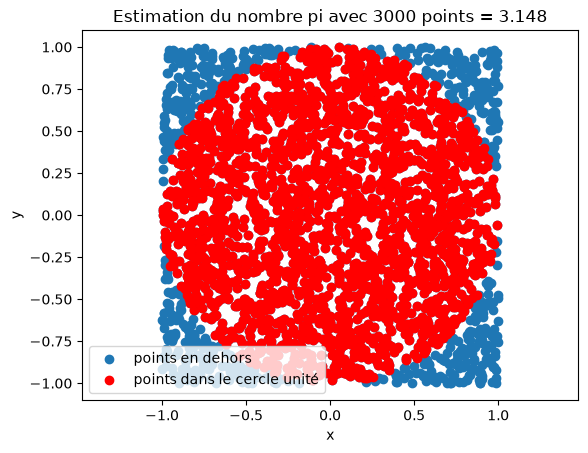

In [8]:
rng = np.random.default_rng(0)
points = rng.uniform(-1, 1, size=(3000,2))
points2=points**2
dedans=points[points2.sum(axis=1)<=1] 
formededans=np.array(np.shape(dedans)).astype(np.float64)
formetotal=np.array(np.shape(points)).astype(np.float64)
pi=(formededans[0]/formetotal[0])*4
plt.scatter(points[:,0], points[:,1], label='points en dehors')
plt.scatter(dedans[:,0], dedans[:,1], c='red', label='points dans le cercle unité')
plt.title(f"Estimation du nombre pi avec 3000 points = {pi}")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.savefig("piestim.png", dpi=120)
plt.show()

````{admonition} Pas encore vu en cours : np.logspace et plt.loglog
:class: note

`np.logspace(2, 6, 9)` donne 9 valeurs régulièrement espacées *en échelle logarithmique* entre $10^2$ et $10^6$ : en clair, c'est `linspace` appliqué aux exposants. `plt.loglog(x, y)` trace comme `plt.plot` mais avec les deux axes en échelle logarithmique, où une loi de puissance $y = x^a$ apparaît comme une droite de pente $a$. On reverra les figures en séance 5.
````

**A.3** Étudions maintenant la convergence. Pour chaque `n` de `ns = np.logspace(2, 6, 9).astype(int)` (de 100 à 1 000 000), calculez l'erreur absolue $|\hat\pi_n - \pi|$, moyennée sur 5 graines différentes (`seed = 0, 1, 2, 3, 4`) afin de lisser le hasard. Rangez les résultats dans un tableau `erreurs` de forme `(9,)`.

Tracez ensuite `erreurs` en fonction de `ns` en échelle log-log (`plt.loglog`) avec des marqueurs, et superposez la droite de référence $1 / \sqrt{n}$ en pointillés. Nommez les axes, ajoutez une légende et un titre, puis enregistrez la figure dans `pi.png` (`plt.savefig("pi.png")`, **avant** `plt.show()`).

Enfin, dans une cellule Markdown : que constatez-vous sur la pente ? Et combien de points faut-il, en ordre de grandeur, pour gagner une décimale de précision ?

````{admonition} Indices
:class: tip

Ici, une boucle Python sur les 9 valeurs de `n` et sur les 5 graines est tout à fait acceptable (cela ne fait que 45 appels) : ce sont les *points* qu'on ne doit pas parcourir un à un.
````

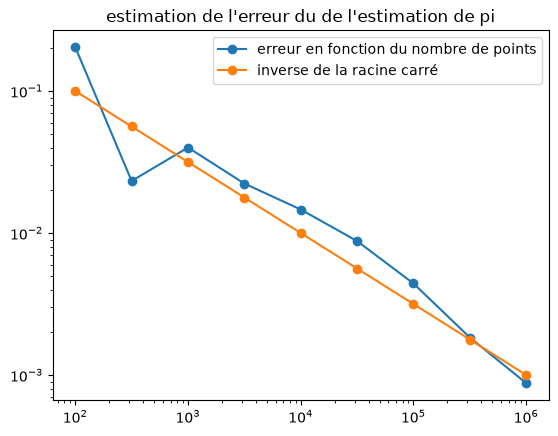

In [11]:
ns = np.logspace(2, 6, 9).astype(int)
erreurtemp = np.empty(shape=(9,))
for i in range (0,5):
    for j in range (len(ns)) :
        erreurtemp[j]+=(np.abs(estimer_pi(ns[j], i)-np.pi))
erreurs=erreurtemp/5
plt.loglog(ns, erreurs, marker='o', label="erreur en fonction du nombre de points")
plt.loglog(ns, 1/np.sqrt(ns), marker = 'o', label='inverse de la racine carré')
plt.title("estimation de l'erreur du de l'estimation de pi")
plt.savefig("pi.png")
plt.legend()
plt.show()

La pente correspond à un coefficient de directeur de -1, l'erreur est logarithmiquement inversemenent proportionnelle au nombre d'essais, en 1/racine(n). On doit multiplier par 10 le nombre de points pour gagner une décimale de précision.

In [12]:
assert ns.shape == (9,) and ns[0] == 100 and ns[-1] == 1_000_000
assert erreurs.shape == (9,)
assert erreurs[-1] < erreurs[0]
assert erreurs[-1] < 0.01
assert os.path.exists("pi.png")
print("ok")

ok


## Partie B – Marches aléatoires dans le plan (6 pts)

Un marcheur part de l'origine et, à chaque pas, se déplace d'une unité dans l'une des quatre directions (est, ouest, nord, sud), choisie au hasard. Nous allons simuler `K = 500` marcheurs faisant chacun `n = 1000` pas — et tout cela d'un coup, sans la moindre boucle !

````{admonition} Pas encore vu en cours : l'indexation par un tableau d'entiers
:class: note

Au lieu d'un entier ou d'une slice, on peut indexer un tableau par un *tableau d'indices* : `np.array([10, 20, 30])[np.array([0, 2, 2, 1])]` renvoie `[10, 30, 30, 20]`. Le résultat a la forme du tableau d'indices, et si le tableau indexé a plusieurs dimensions, chaque indice est remplacé par la ligne correspondante. C'est une notion optionnelle du cours (notebook `1-14`).
````

````{admonition} Pas encore vu en cours : la somme cumulée cumsum
:class: note

`tab.cumsum(axis=...)` ne renvoie pas un total, mais tous les totaux intermédiaires : `np.array([2, 3, 1]).cumsum()` vaut `[2, 5, 6]`. Le résultat a exactement la même forme que le tableau de départ, et `axis=` désigne la dimension le long de laquelle on accumule. C'est précisément ce qui transforme une suite de déplacements en une suite de positions.
````

**B.1** Avec un générateur de graine 0 :

* tirez `tirages = rng.integers(0, 4, size=(K, n))` : le numéro de direction de chaque pas de chaque marcheur ;
* définissez la table `directions`, un tableau `(4, 2)` contenant les quatre déplacements `(1, 0)`, `(-1, 0)`, `(0, 1)`, `(0, -1)` ;
* calculez `pas = directions[tirages]`. Quelle est la forme de `pas` ?
* calculez `positions`, les positions successives de chaque marcheur, par somme cumulée le long de l'axe des pas.

In [13]:
tirages = rng.integers(0, 4, size=(500, 1000))
directions = (np.array([(1, 0), (-1, 0), (0, 1), (0, -1)])).reshape(4,2)
pas =  directions[tirages]
print(pas.shape)
positions=pas.cumsum(axis=1)

(500, 1000, 2)


Pour la forme de pas, on a 500 tableaux des mille pas (tuples) aléatoires pour chaque marcheur.

In [14]:
assert tirages.shape == (500, 1000)
assert directions.shape == (4, 2)
assert pas.shape == (500, 1000, 2)
assert positions.shape == (500, 1000, 2)
assert np.all(np.abs(pas).sum(axis=2) == 1)          # chaque pas a une longueur 1
assert np.array_equal(positions[:, 0, :], pas[:, 0, :])
assert np.array_equal(positions[:, -1, :], pas.sum(axis=1))
print("ok")

ok


**B.2** Intéressons-nous maintenant aux distances. Calculez :

* `finales` : les positions finales des `K` marcheurs, forme `(K, 2)` ;
* `distances` : leur distance à l'origine, forme `(K,)` ;
* comparez la racine de la moyenne des distances au carré à $\sqrt{n}$, et la distance moyenne à $\sqrt{\pi n} / 2 \approx 0{,}886\sqrt{n}$.
* Quelle proportion des marcheurs termine à moins de 20 unités de l'origine ? Et quelle est la distance maximale atteinte par un marcheur *au cours* de sa marche, et pas seulement à la fin ? Pour cette dernière, calculez `dist_t`, tableau `(K, n)` des distances à l'origine à chaque instant.

In [15]:
n=1000
finales=positions[:,-1,:]
finales2=finales**2
distances = np.array(np.sqrt(finales2[:,0]+finales2[:,1]))
moy = np.mean(distances[:])
print(moy, np.sqrt(1000))
print(moy, (np.sqrt(np.pi*1000)/2))
prop20=distances[distances<=20]
print((len(prop20)/len(distances)))
positions2=positions**2
dist_t=np.array(np.sqrt(positions2[:,:,0]+positions2[:,:,1]))
max_dist=dist_t.max()
print(max_dist)

28.227340962891464 31.622776601683793
28.227340962891464 28.024956081989643
0.334
86.03487664894976


Pour mon test, en moyenne 26.9 unités à la fin, comparé racine(1000)=31 et pondérée qui vaut 28,0 (plus proche).
La part de ceux qui terminent à moins de 20 unités est 0.372 et le plus loin va à 89,8 au cours de sa marche.

In [16]:
assert finales.shape == (500, 2) and distances.shape == (500,)
rms = np.sqrt((distances**2).mean())
assert 0.85 * np.sqrt(n) < rms < 1.15 * np.sqrt(n)
assert dist_t.shape == (500, 1000)
assert np.all(dist_t.max(axis=1) >= distances)
print("ok")

ok


**B.3** Passons à la figure `marche.png` : tracez les trajectoires des 5 premiers marcheurs (`plt.plot(x, y)` avec une couleur par marcheur), marquez l'origine d'un point noir, et pensez à `plt.axis("equal")`, au titre et à la légende. Enregistrez le tout dans `marche.png`.

Puis, dans une seconde figure (pas besoin de l'enregistrer, celle-là), tracez la distance moyenne à l'origine en fonction du temps, `dist_t.mean(axis=0)`, et superposez la courbe $0{,}886\sqrt{t}$ pour `t = np.arange(1, n + 1)`. Commentez en une phrase ce que vous observez.

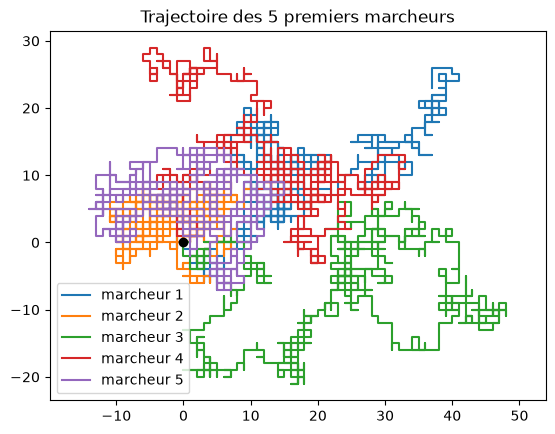

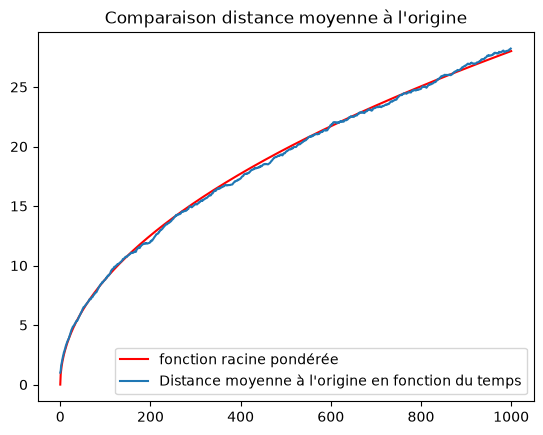

In [17]:
for i in range(0,5):
    plt.plot(positions[i,:,0], positions[i,:,1], label=f'marcheur {i+1}')
plt.plot(0,0, marker = 'o', c='black')
plt.axis("equal")
plt.title('Trajectoire des 5 premiers marcheurs')
plt.legend()
plt.savefig("marche.png")
plt.show()
t=np.arange(0,1001)

def f(x): 
    return 0.886*(np.sqrt(x))
plt.plot(t, f(t), c='red', label='fonction racine pondérée')
plt.plot(dist_t.mean(axis=0), label="Distance moyenne à l'origine en fonction du temps")
plt.title("Comparaison distance moyenne à l'origine")
plt.legend()
plt.show()

In [18]:
assert os.path.exists("marche.png")
print("ok")

ok


**B.4** Terminons par un peu de masques : sans boucle, calculez la proportion de marcheurs qui repassent par l'origine au moins une fois après le départ, c'est-à-dire dont la position vaut `(0, 0)` à un instant quelconque.

In [38]:
retour1=(positions[:,:,0]==0) & (positions[:,:,1]==0)
retour=np.any(retour1, axis=1)
proportion=retour.mean()
print(proportion)

0.698


In [39]:
assert retour.shape == (500,) and retour.dtype == bool
assert 0.5 < retour.mean() < 0.95
print("ok")

ok


## Partie C – L'ensemble de Mandelbrot (6 pts)

Pour un nombre complexe $c$, on itère $z_0 = 0$, $z_{k+1} = z_k^2 + c$. Si la suite reste bornée, $c$ appartient à l'ensemble de Mandelbrot ; or, dès que $|z_k| > 2$, on est certain qu'elle diverge, ce qui nous donne un critère d'arrêt simple. On colorie alors chaque point $c$ du plan selon le nombre d'itérations effectuées avant que $|z_k|$ ne dépasse 2, avec un plafond `max_iter` pour les points qui ne divergent pas.

**C.1** Écrivez `grille(xmin, xmax, ymin, ymax, nx, ny)` qui renvoie le tableau complexe `c` de forme `(ny, nx)` tel que `c[i, j] = x[j] + 1j * y[i]`, avec `x = np.linspace(xmin, xmax, nx)` et `y = np.linspace(ymin, ymax, ny)`. Utilisez le *broadcasting* vu en séance 2 (`np.newaxis` ou `reshape`).

In [19]:
def grille(xmin, xmax, ymin, ymax, nx, ny) : 
    x=np.linspace(xmin, xmax, nx)
    y=np.linspace(ymin, ymax, ny)
    ynew=y[:,None]
    c=x+ynew*1j
    return(c)

In [20]:
g = grille(-2, 1, -1.5, 1.5, 4, 3)
assert g.shape == (3, 4)
assert g.dtype == complex
assert g[0, 0] == -2 - 1.5j and g[2, 3] == 1 + 1.5j and g[1, 0] == -2 + 0j
print("ok")

ok


````{admonition} Pas encore vu en cours : np.errstate
:class: note

Certains calculs `numpy` (dépassement de capacité, `inf`, `nan`) produisent un `RuntimeWarning` sans interrompre le programme. `np.errstate` fait taire ces avertissements sur une portion de code :

```python
with np.errstate(over="ignore", invalid="ignore"):
    resultat = mon_calcul()
```

Ne l'utilisez que lorsque vous avez compris d'où viennent les avertissements et que vous les jugez inoffensifs !
````

**C.2** Écrivez `mandelbrot(c, max_iter=100)` qui renvoie un tableau d'entiers `n_iter`, de même forme que `c`, contenant pour chaque point le nombre d'itérations pendant lesquelles $|z_k| \le 2$ (donc `max_iter` pour les points de l'ensemble).

La seule boucle Python autorisée est celle sur les itérations : à chaque tour, tous les points de `c` sont mis à jour d'un coup.

Un mot d'avertissement : les points qui divergent "explosent" rapidement vers `inf` ou `nan`, ce qui déclenche des avertissements (`RuntimeWarning: overflow`, `invalid value`). Ils sont sans gravité ici, et vous pourrez les faire taire en entourant l'appel de `with np.errstate(over="ignore", invalid="ignore"):` — ou vous en débarrasser pour de bon, cf. le bonus.

In [21]:
def mandelbrot(c, max_iter=100):
    z=np.zeros(c.shape, dtype=np.complex128)
    n_iter = np.zeros(c.shape, dtype=np.uint8)
    for k in range(max_iter):
        z = z**2 + c
        n_iter += (np.abs(z) <= 2)
    return n_iter

In [22]:
with np.errstate(over="ignore", invalid="ignore"):
    m = mandelbrot(grille(-2, 1, -1.5, 1.5, 300, 300), max_iter=50)
assert m.shape == (300, 300)
assert m.dtype.kind in "iu"
assert m.max() == 50 and m.min() >= 0
assert m[150, 100] == 50          # c ≈ -1 : dans l'ensemble
assert m[0, 0] <= 2               # c = -2 - 1.5i : diverge tout de suite
assert m[150, 250] <= 5           # c ≈ 0.5 : diverge vite
assert 0.14 < (m == 50).mean() < 0.21   # aire de l'ensemble ≈ 1.5 sur un cadre de 9
print("ok")

ok


**C.3** Passons à la figure `mandelbrot.png` : calculez `mandelbrot` sur la grille `[-2, 1] × [-1.5, 1.5]` avec `nx = 900`, `ny = 900` et `max_iter = 100`, puis affichez le résultat avec `plt.imshow(..., extent=[xmin, xmax, ymin, ymax], origin="lower")` afin que les axes soient gradués en coordonnées complexes, et non en numéros de pixel. Ajoutez `plt.colorbar(label="itérations")`, les noms d'axes (partie réelle / partie imaginaire), un titre, et enregistrez dans `mandelbrot.png`.

Enfin, dans une cellule Markdown : que vaut `n_iter` pour les points de l'ensemble, et comment les reconnaît-on sur l'image ?

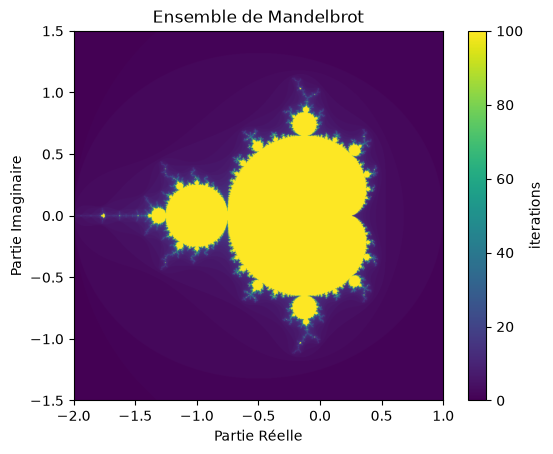

In [27]:
with np.errstate(over="ignore", invalid="ignore"):
    g=g = grille(-2, 1, -1.5, 1.5, 900, 900)
    M=mandelbrot(g, max_iter=100)
    plt.imshow(M, extent=[-2, 1, -1.5, 1.5], origin="lower")
    plt.colorbar(label="itérations")
    plt.title("Ensemble de Mandelbrot")
    plt.xlabel("Partie Réelle")
    plt.ylabel("Partie Imaginaire")
    plt.savefig("mandelbrot.png")
    plt.show()

Pour les points de l'ensemble, n_iter=100, ce sont tous les points qui, sur l'image, apparaissent en jaune.

In [29]:
assert M.shape == (900, 900)
assert os.path.exists("mandelbrot.png")
print("ok")

ok


## Bonus (+2)

**Bo.1** Un zoom, pour commencer : calculez et affichez la zone `[-0.8, -0.7] × [0.05, 0.15]` — la « vallée des hippocampes » — avec `max_iter = 300`, toujours avec `extent`. Essayez au passage une autre palette (`cmap="twilight"`, `"inferno"`, `"viridis"`, …).

**Bo.2** Puis une version sans aucun avertissement, et sans `np.errstate` : au lieu de mettre à jour `z` partout, ne mettez à jour que les points encore actifs, à l'aide d'un masque booléen et de l'indexation par masque (attention à compter exactement comme `mandelbrot` !). Vérifiez que le résultat est identique (`np.array_equal`) à celui de `mandelbrot` sur la grille de C.2, puis comparez les temps d'exécution avec `%timeit`.

In [ ]:
# votre code

Bon courage à tous ! Pour toute question sur le sujet, vous pouvez me contacter par email : [aurelien.noce@imagine-app.fr](mailto:aurelien.noce@imagine-app.fr).

Au plaisir de vous lire,

votre responsable de cours, Aurélien Noce